need to redo this...

I think it came from pipeline: (full_image) coregistration, normalize into SUIT space, then summarize ('space' = SUIT)

or (ignoring this) we can do this same analysis with our normalized white matter images in MNI Symmetric space.

So what we'll have is:

- slope images in MNI Symmetric space - analyze those

- white matter segmentations normalized to MNISym template - perform this analysis on them (ipsi-, contra-lesional, vermis, controls)

# Total white matter volume analysis (deprecated?)

Prelimary analysis on total WMV in ROIs defined by atlas "Diedrichsen_2009" (with anatomical labels).

To deal with missing data, use the regression function.

To deal with individual differences, work with intracranial total volume

In [1]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

In [2]:
p_df = pd.read_csv(f'{gl.baseDir}/participants_anat.tsv', sep = '\t')

## Step 1

Look at total wmv in cerebellum for only those subjects that have (a) >1 measurement weeks, (b) W0

Look at weekly WMV relative to W0

There are two ways to get tWMV:

- Use sum of WMV from SUIT-based ROIs (bandage solution)

- calculate total volume of white matter from sum of voxels

In both of these, use tissue extractor module (summarize function...under construction) to get the df

In [3]:
df = pd.read_csv(f'{gl.baseDir}/wmv_total_atlas_summarized.tsv', sep = '\t')

In [4]:
df

,image,image_name,frame,region,regionname,volume,atlas,map,space,avg_wmv,...,ID,Week,Centre,RefT1,age,Gender,isPatient,LesionSide,LesionLocation,handedness
0,1,wmv_img_CU_2310_W0_T1.nii,0,1,Left_I_IV,4895.0,Diedrichsen_2009,atl-Anatom,SUIT,0.108778,...,2310.0,W0,CU,W0,57,M,1,left,subcortical,2
1,1,wmv_img_CU_2310_W0_T1.nii,0,2,Right_I_IV,5491.0,Diedrichsen_2009,atl-Anatom,SUIT,0.099815,...,2310.0,W0,CU,W0,57,M,1,left,subcortical,2
2,1,wmv_img_CU_2310_W0_T1.nii,0,3,Left_V,6052.0,Diedrichsen_2009,atl-Anatom,SUIT,0.074112,...,2310.0,W0,CU,W0,57,M,1,left,subcortical,2
3,1,wmv_img_CU_2310_W0_T1.nii,0,4,Right_V,5968.0,Diedrichsen_2009,atl-Anatom,SUIT,0.062802,...,2310.0,W0,CU,W0,57,M,1,left,subcortical,2
4,1,wmv_img_CU_2310_W0_T1.nii,0,5,Left_VI,12562.0,Diedrichsen_2009,atl-Anatom,SUIT,0.061881,...,2310.0,W0,CU,W0,57,M,1,left,subcortical,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7101,1,wmv_img_UZP_1008_W52_T1.nii,0,30,Right_Dentate,2051.0,Diedrichsen_2009,atl-Anatom,SUIT,0.987619,...,1008.0,W52,UZP,W0,63,M,0,none,none,2
7102,1,wmv_img_UZP_1008_W52_T1.nii,0,31,Left_Interposed,281.0,Diedrichsen_2009,atl-Anatom,SUIT,0.976948,...,1008.0,W52,UZP,W0,63,M,0,none,none,2
7103,1,wmv_img_UZP_1008_W52_T1.nii,0,32,Right_Interposed,279.0,Diedrichsen_2009,atl-Anatom,SUIT,0.985331,...,1008.0,W52,UZP,W0,63,M,0,none,none,2
7104,1,wmv_img_UZP_1008_W52_T1.nii,0,33,Left_Fastigial,54.0,Diedrichsen_2009,atl-Anatom,SUIT,0.946126,...,1008.0,W52,UZP,W0,63,M,0,none,none,2


In [ ]:
# get numeric value - for numerical ordering (in aggregate below); with 'W0', ..., it will order lexicographically, so out of order
df.week = df.Week.str.strip('W').astype(int)

In [21]:
df['hemisphere'] = df['regionname'].str[0]

# subjects with W0
diff_df = pd.DataFrame()

for subj in df['subj_id'].unique():
    refT1 = (df.loc[(df['subj_id']==subj), 'RefT1'].iloc[0]).strip()
    if not refT1=='W0':
        print(subj, "skipped")
        continue
    diff_df = pd.concat([diff_df, df[df['subj_id']==subj]])

CU_2697 skipped
JHU_2282 skipped
JHU_2577 skipped
JHU_2684 skipped
JHU_3176 skipped
UZ_2365 skipped
UZ_2450 skipped
UZ_2595 skipped
UZ_3030 skipped
UZ_3224 skipped
UZ_3228 skipped


In [28]:
# total wmv per week

week_vols = diff_df.groupby(['subj_id', 'week', 'Week', 'isPatient', 
                             'hemisphere', 'LesionSide', 'LesionLocation', 'RefT1']
                             ).agg({'ind_vol': 'sum'}
                             ).reset_index()

In [30]:
# change in total WM volume relative to the first week per hemisphere (left, right, vermis)

#for subj in week_vols.loc[week_vols['isPatient']==1, 'subj_id'].unique():
for subj in week_vols['subj_id'].unique():
    for week in week_vols.loc[week_vols['subj_id']==subj, 'Week'].unique():
        for hem in week_vols.loc[week_vols['subj_id']==subj, 'hemisphere'].unique():
            curr_vol = week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['Week'] == week) & (week_vols['hemisphere'] == hem), 'ind_vol'].iloc[0]

            ref_vol = week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['Week'] == refT1) & (week_vols['hemisphere'] == hem), 'ind_vol'].iloc[0]
            week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['Week'] == week) & (week_vols['hemisphere'] == hem), 'vol_diff'] = curr_vol - ref_vol

In [31]:
week_vols

,subj_id,week,Week,isPatient,hemisphere,LesionSide,LesionLocation,RefT1,ind_vol,vol_diff
0,CUP_1001,0,W0,0,L,none,none,W0,9053.748888,0.000000
1,CUP_1001,0,W0,0,R,none,none,W0,8894.183198,0.000000
2,CUP_1001,0,W0,0,V,none,none,W0,500.239134,0.000000
3,CUP_1001,4,W4,0,L,none,none,W0,6820.745517,-2233.003372
4,CUP_1001,4,W4,0,R,none,none,W0,6378.704657,-2515.478541
...,...,...,...,...,...,...,...,...,...,...
517,UZ_3248,24,W24,1,R,left,subcortical,W0,5665.700926,-201.651973
518,UZ_3248,24,W24,1,V,left,subcortical,W0,374.335020,-0.517928
519,UZ_3248,52,W52,1,L,left,subcortical,W0,6451.555167,278.655807
520,UZ_3248,52,W52,1,R,left,subcortical,W0,5555.327662,-312.025237


In [36]:
# create dummy column: ipsilesional = 0, contralesional = 1, none = 2 (no stroke), vermis = 3

hem_dict = {
    'L': 'left',
    'R': 'right',
    'V': 'vermis'
}

week_vols['hemisphere'] = week_vols['hemisphere'].map(hem_dict) # hem names should match LesionSide names
# we can use this naming convention in all subsequent cells, so it's fine

lesion_namings = {'L': 'left', 'R': 'right', 'l': 'left', 'r': 'right',
              'Left': 'left', 'Right': 'right', 'left': 'left', 'right': 'right'}
week_vols['LesionSide'] = week_vols['LesionSide'].astype(str).str.strip()

week_vols['side_type'] = 2 # default none

# for patient rows: set ipsi-, contra-lesional, vermis
mask_patient = week_vols['isPatient']==1
mask_hemi_lr = week_vols['hemisphere'].isin(['left', 'right']) # for l, r hem, assign ipsilesional or contralesional

week_vols.loc[mask_patient & (week_vols['hemisphere'] == week_vols['LesionSide']), 'side_type'] = 0 # ipsi
week_vols.loc[mask_patient & mask_hemi_lr & (week_vols['hemisphere'] != week_vols['LesionSide']), 'side_type'] = 1 # contra
week_vols.loc[mask_patient & (week_vols['hemisphere'] == 'vermis'), 'side_type'] = 3 # vermis

In [37]:
# put descriptive titles on plots
titles = {
    '0': 'ipsilesional',
    '1': 'contralesional',
    '2': 'control',
    '3': 'vermis'
}

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


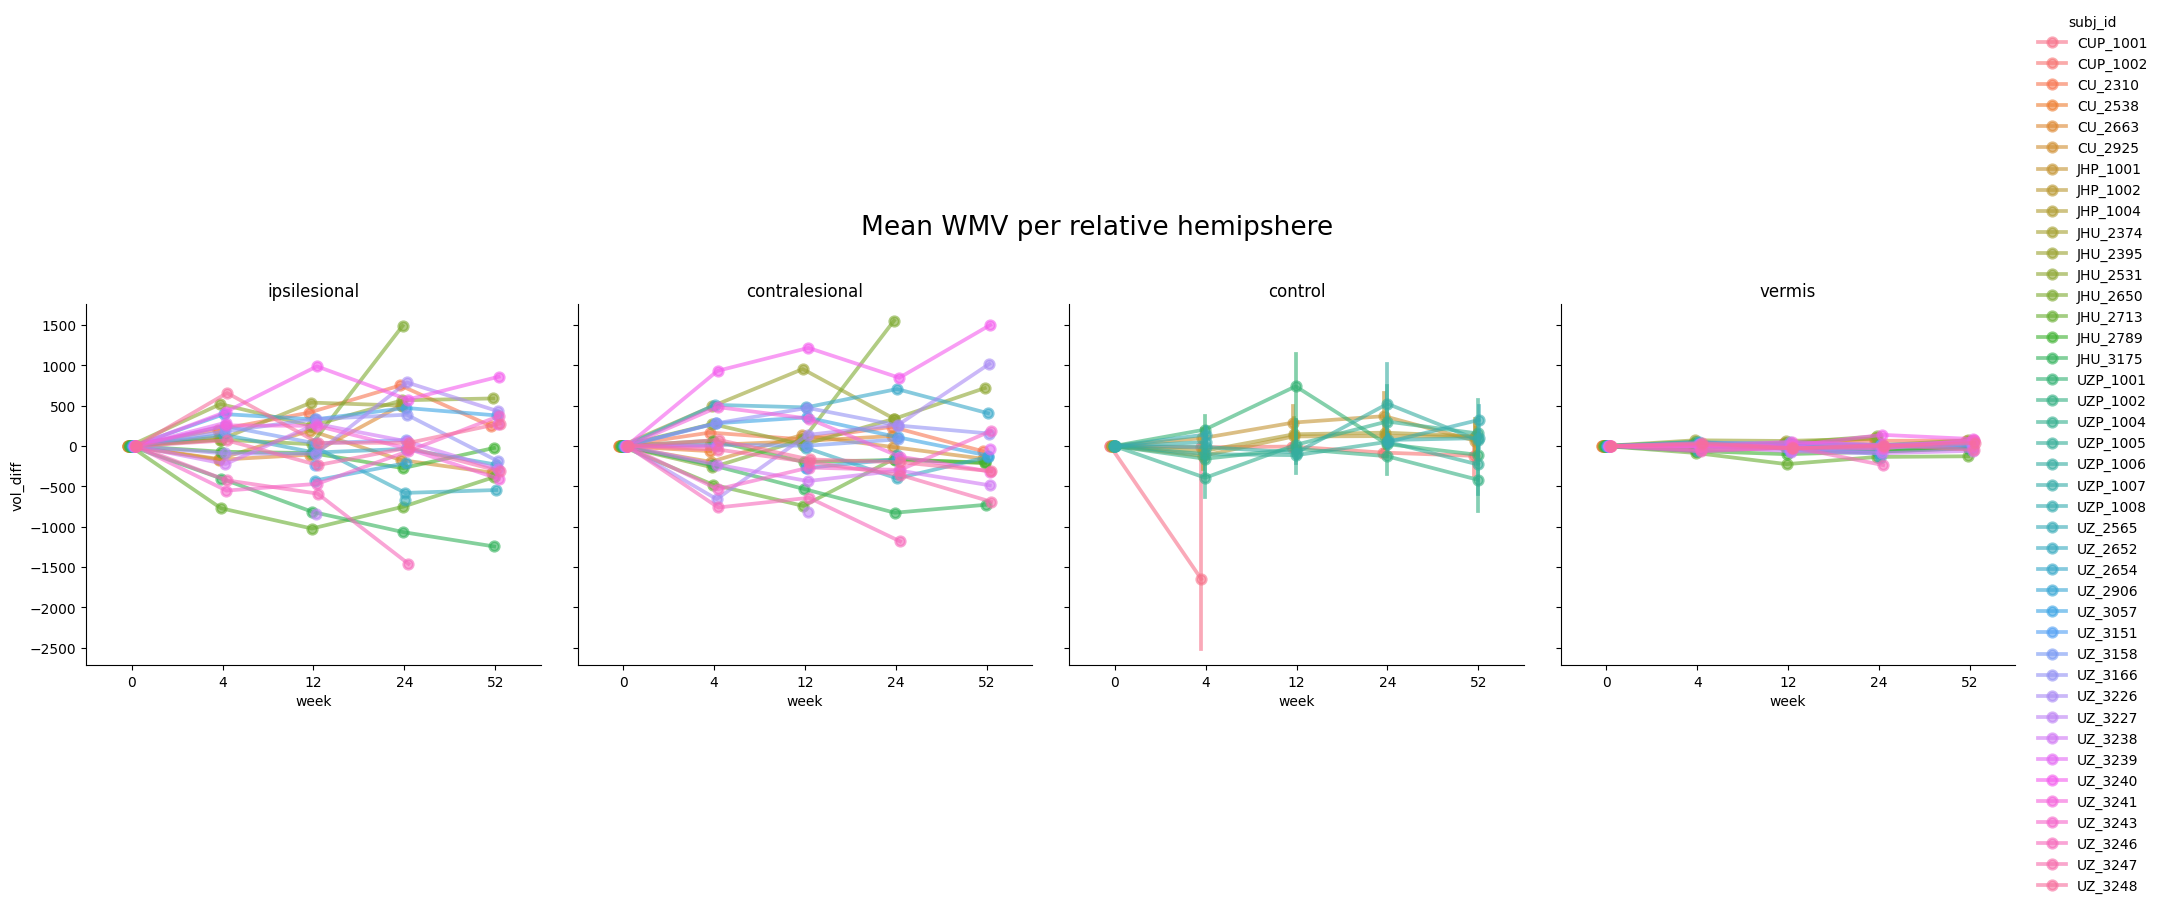

In [38]:
diff_plots_wmv_mean = sns.catplot(data = week_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_mean.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_mean.figure.suptitle('Mean WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_mean.figure.subplots_adjust(top = 0.8)
plt.show()
# vermis is coded as '3', gets its own plot

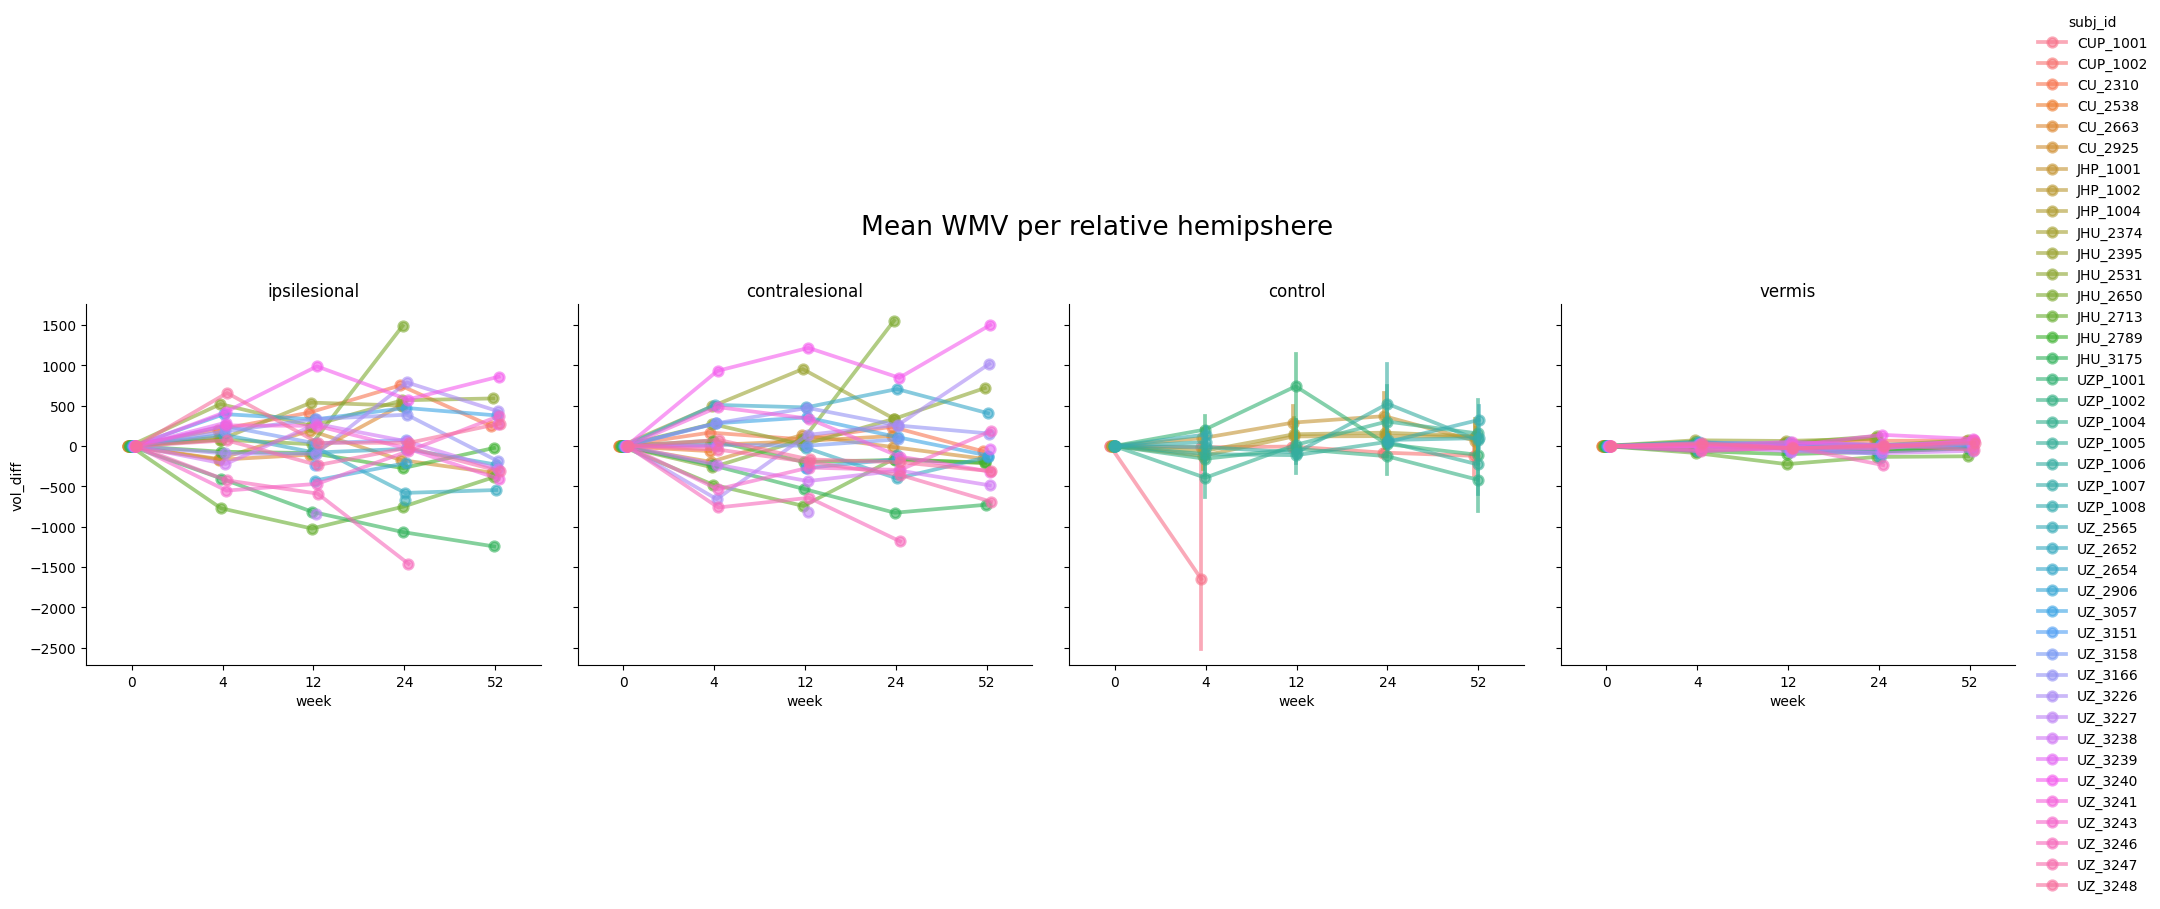
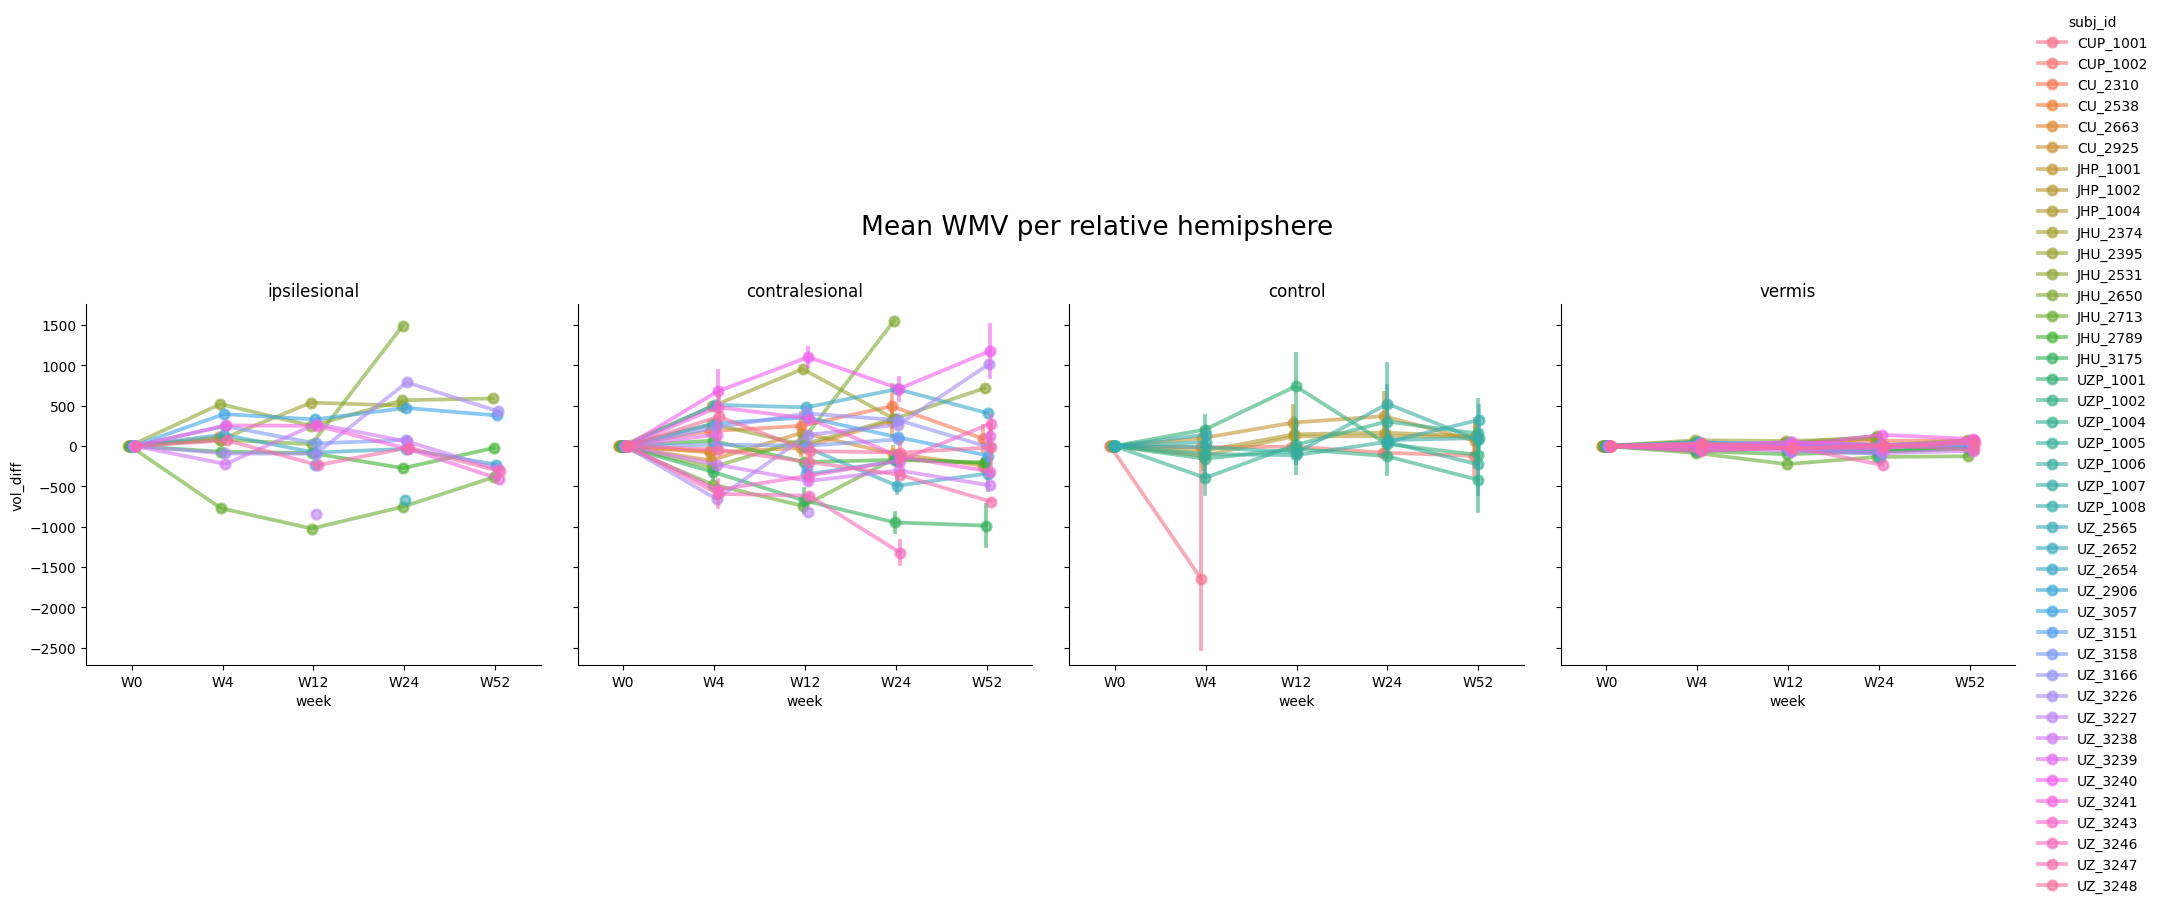

In [40]:
week_vols

,subj_id,week,Week,isPatient,hemisphere,LesionSide,LesionLocation,RefT1,ind_vol,vol_diff,side_type
0,CUP_1001,0,W0,0,left,none,none,W0,9053.748888,0.000000,2
1,CUP_1001,0,W0,0,right,none,none,W0,8894.183198,0.000000,2
2,CUP_1001,0,W0,0,vermis,none,none,W0,500.239134,0.000000,2
3,CUP_1001,4,W4,0,left,none,none,W0,6820.745517,-2233.003372,2
4,CUP_1001,4,W4,0,right,none,none,W0,6378.704657,-2515.478541,2
...,...,...,...,...,...,...,...,...,...,...,...
517,UZ_3248,24,W24,1,right,left,subcortical,W0,5665.700926,-201.651973,1
518,UZ_3248,24,W24,1,vermis,left,subcortical,W0,374.335020,-0.517928,3
519,UZ_3248,52,W52,1,left,left,subcortical,W0,6451.555167,278.655807,0
520,UZ_3248,52,W52,1,right,left,subcortical,W0,5555.327662,-312.025237,1


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


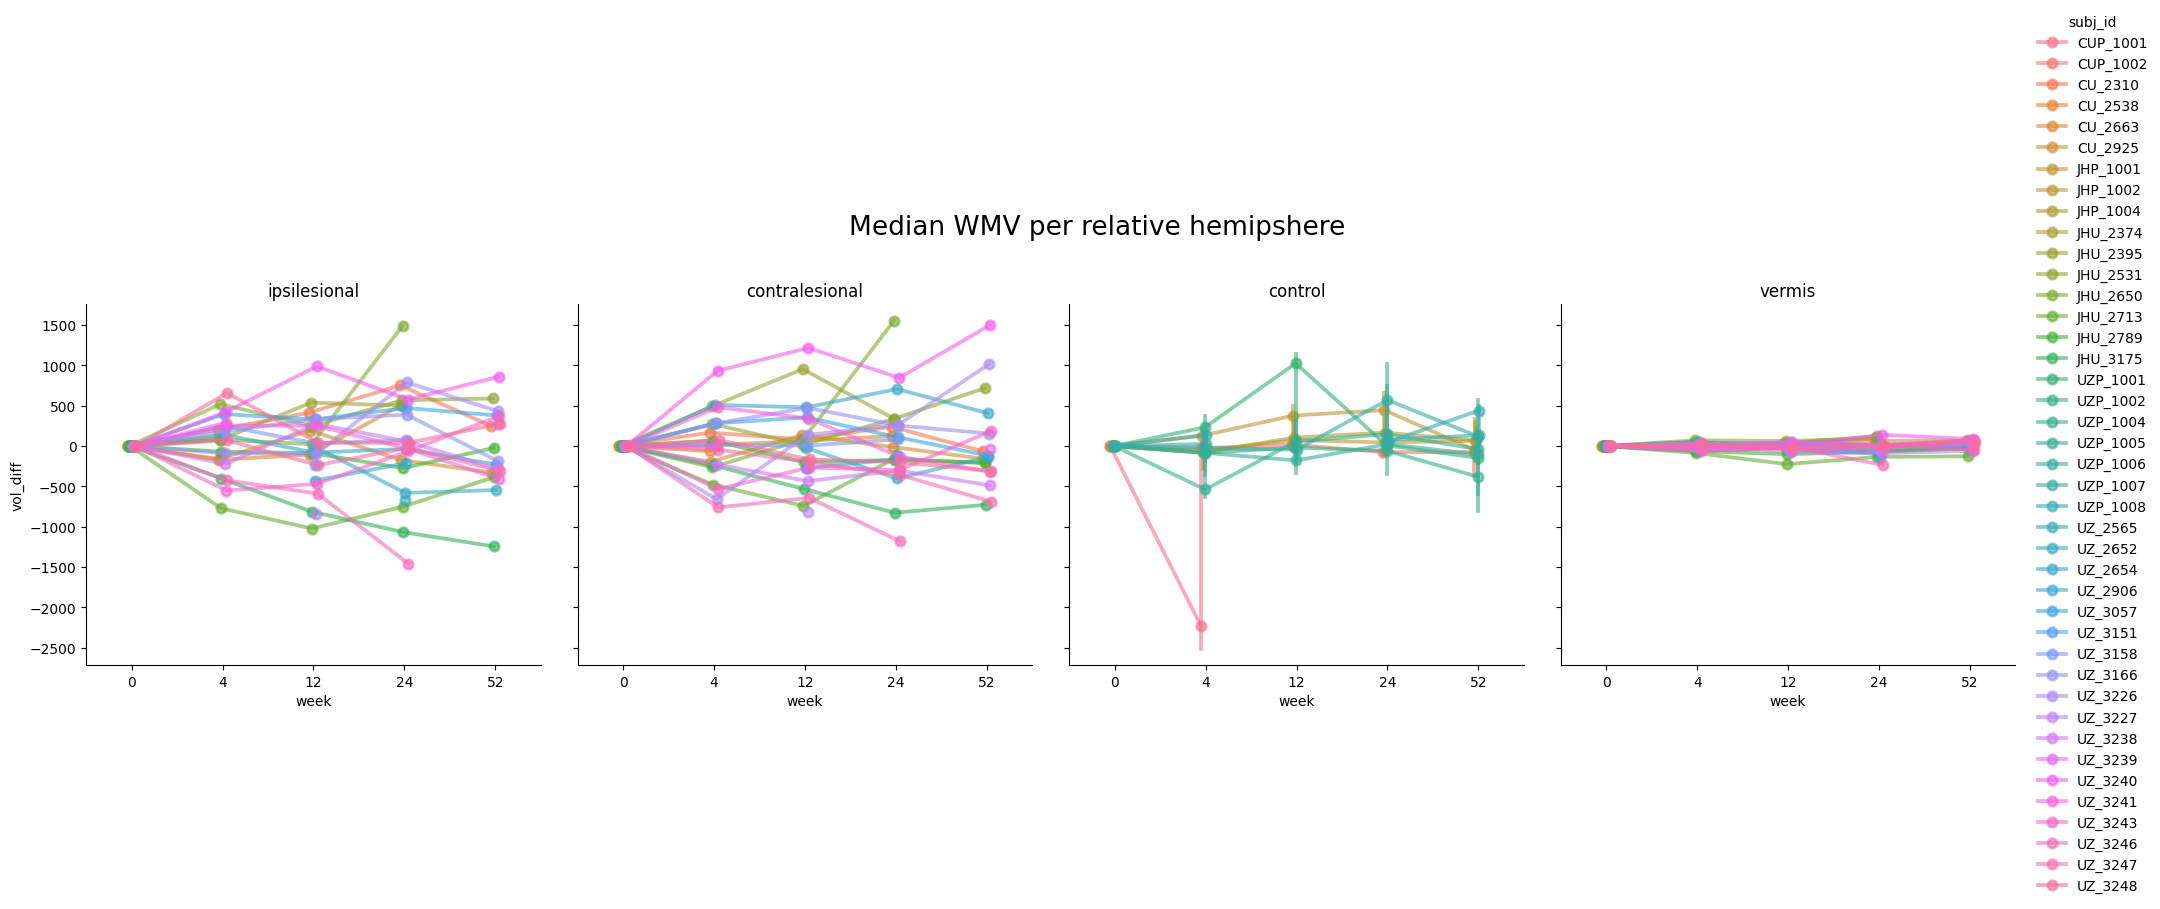

In [42]:
# plot the medians
diff_plots_wmv_median = sns.catplot(data = week_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            estimator = 'median',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_median.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_median.figure.suptitle('Median WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_median.figure.subplots_adjust(top = 0.8)
plt.show()

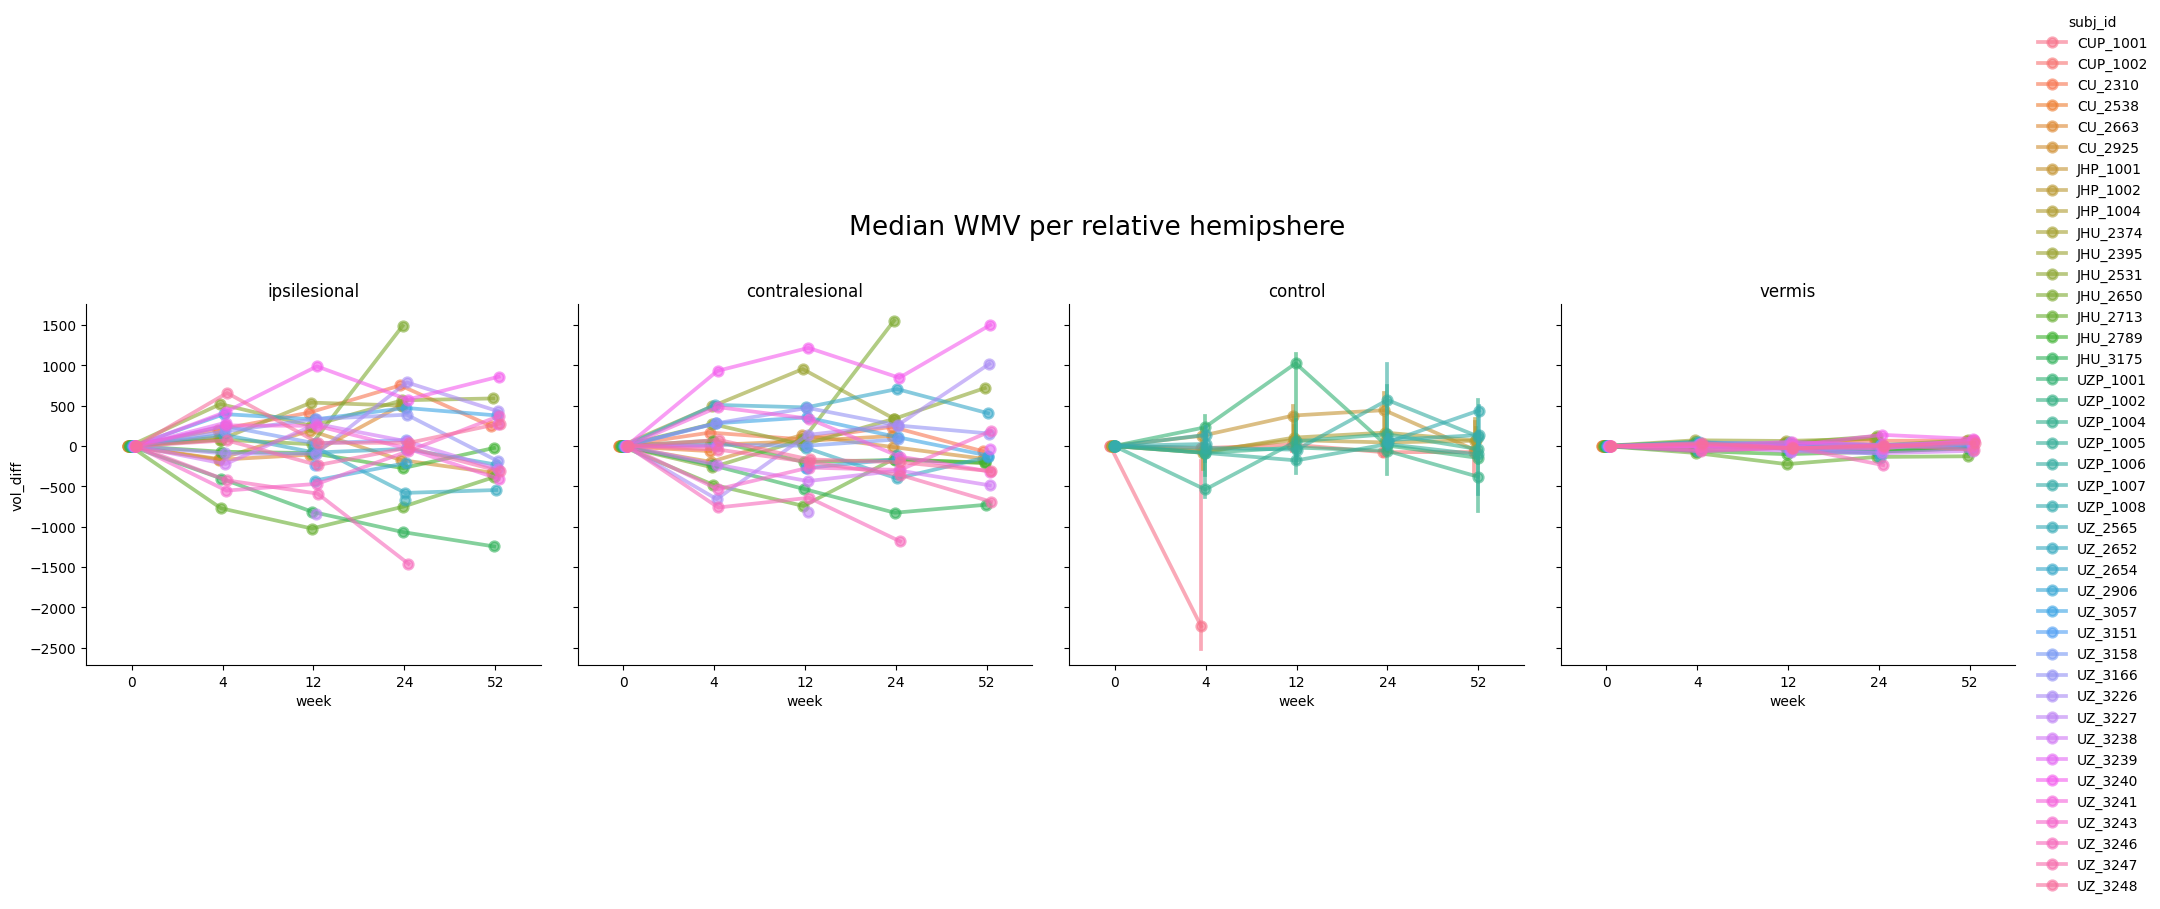
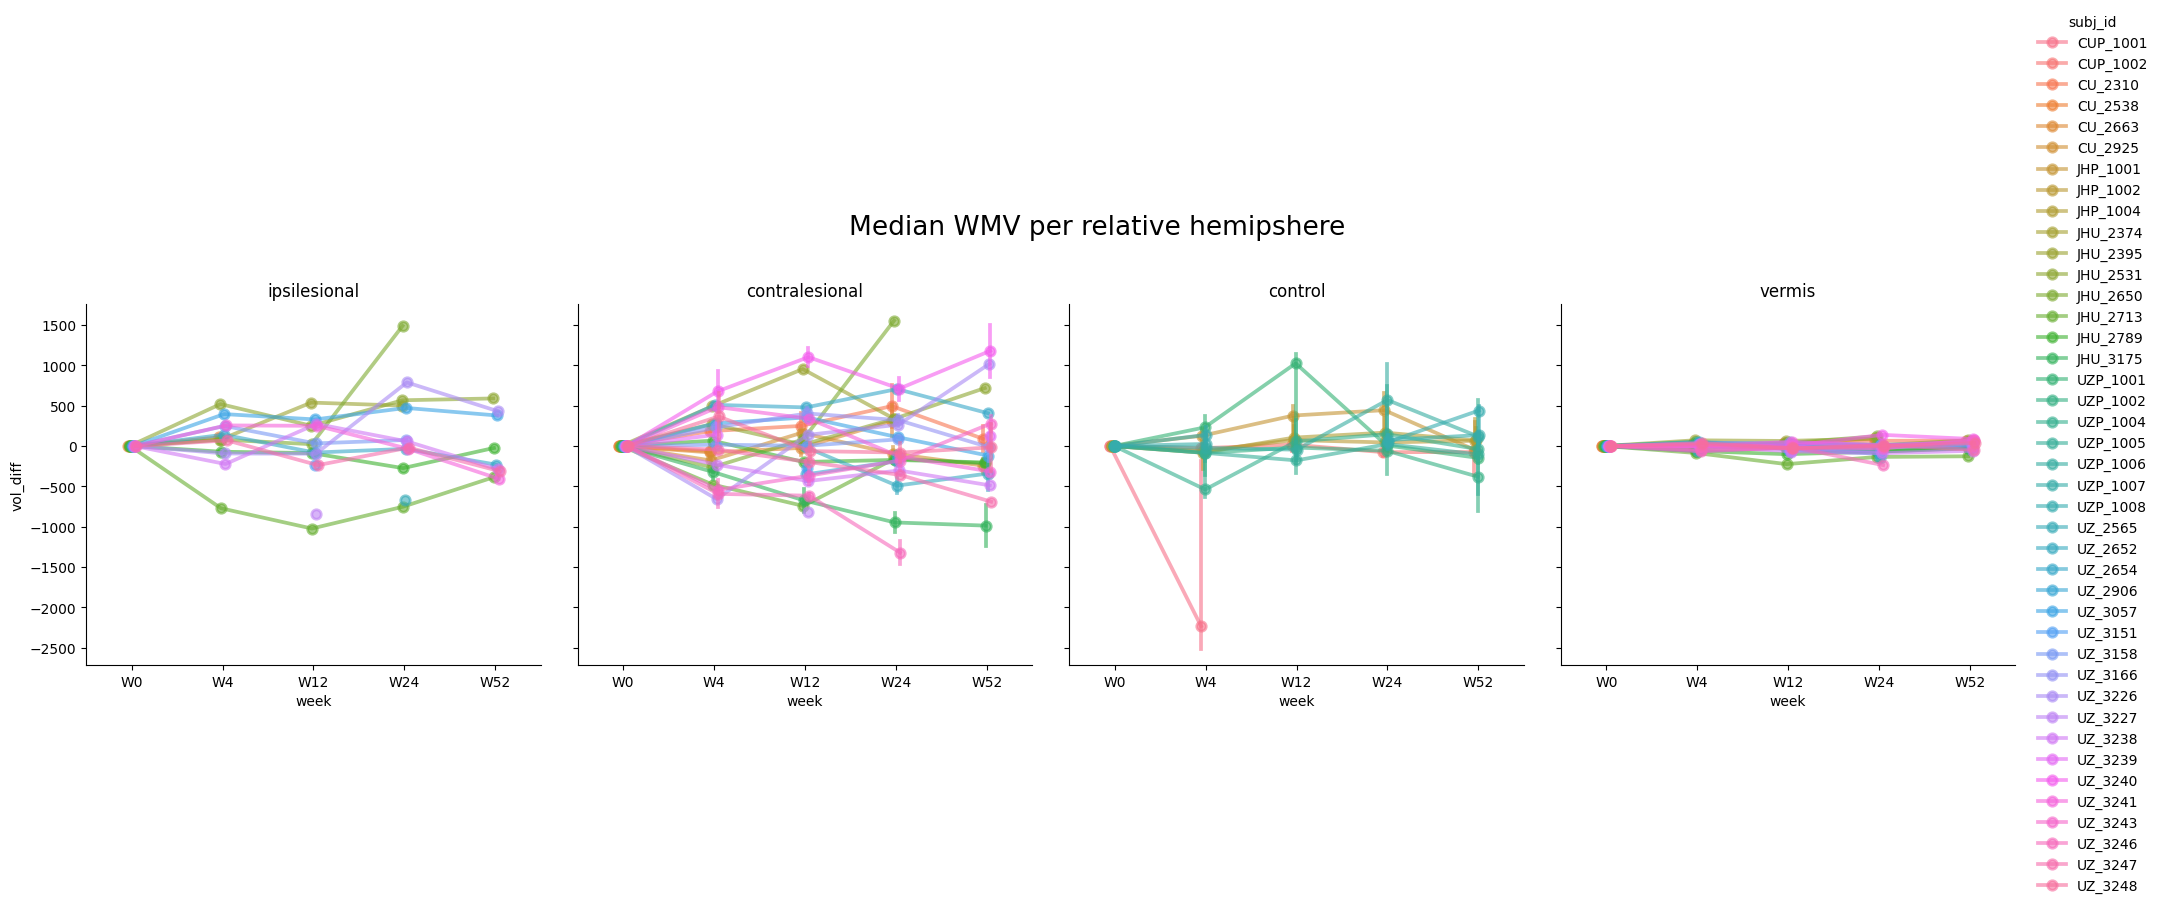